
# Security and Privacy (CC2009) - 25/26
## ASSIGNMENT #1: Performance Benchmarking of Cryptographic Mechanisms
### PL1 - Elements: Amanda Lucas (202400455), Aly Filho (202401045) e Silvia Pinto (202405988)


#### A. Generate random text files with the following sizes: 8, 64, 512, 4096, 32768, 262144, 2097152:
##### Done in ../03 - data<br>
##### We use the **urandom** from **OS** (Python) to generate random files, can be seen in **../02 - scripts/gen_files.py**
---

#### B. Encrypt and decrypt random files with AES in Counter Mode, using the code that you wrote previously:
##### First thing is to define 2 functions, in Python, one to encrypt and another one to decrypt, using the cryptography library from python: We will use Cipher to define a cipher with AES algorithms from algorithms in CTR mode from modes, that can been seen in **../01 - source/aes_ctr.py**
##### Here function 1 receives m (plaintext), the key and nonce and returns c (ciphertext), and function 2 receives c (ciphertext), the key and nonce and return the original text m (plaintext):

In [ ]:
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes

def my_encrypt_aes_ctr(plaintext, key, nonce):
    alg = algorithms.AES(key) 
    mode = modes.CTR(nonce) 
    cypher = Cipher(alg,mode) 

    encrypt = cypher.encryptor()  
    
    return encrypt.update(plaintext) + encrypt.finalize() 

def my_decrypt_aes_ctr(ciphertext, key, nonce):
    alg = algorithms.AES(key) 
    mode = modes.CTR(nonce) 
    cypher = Cipher(alg,mode) 

    decrypt = cypher.decryptor()

    return decrypt.update(ciphertext) + decrypt.finalize()

##### To ensure statistical significance, we automated the benchmarking process using **Pandas** and **NumPy**. We performed repeated executions over the same files to observe temporal variance and across multiple randomly generated files of fixed sizes to evaluate the algorithm's consistency regardless of the input data. For intuitive graphical analysis we use **Matplotlib** and **Seaborn** libraries.


In [1]:
import sys
sys.path.append('../01 - source')
from aes_ctr import df, plot_variation_same_file, plot_comparison_fixed_size, plot_final_scalability

##### Question B.1) Do results change if you run a fixed algorithm over the same file multiple times?

###### Here we are fixing the algorithm over one unique file, that can be seen in function **plot_variation_same_file** in **aes_ctr.py**, and we encrypt and decrypt this fixed file 30 times. To ensure statistical significance, we chose a sample size of **n = 30** repetitions for each cryptographic operation. According to the Central Limit Theorem, a sample size of 30 is sufficient to approximate a normal distribution, allowing for reliable calculations of the standard deviation and confidence intervals, while effectively mitigating the impact of OS-induced latency (CPU jitter) without excessive computational overhead.

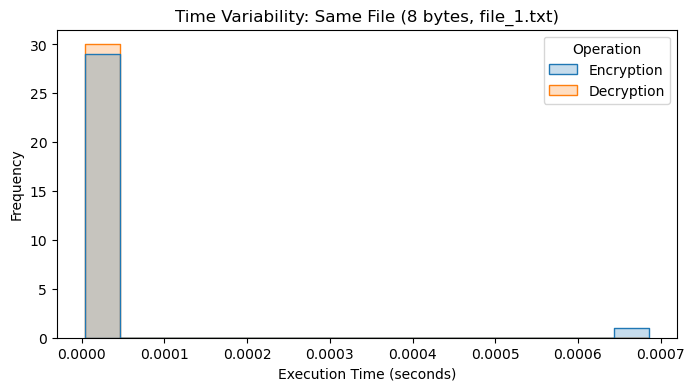

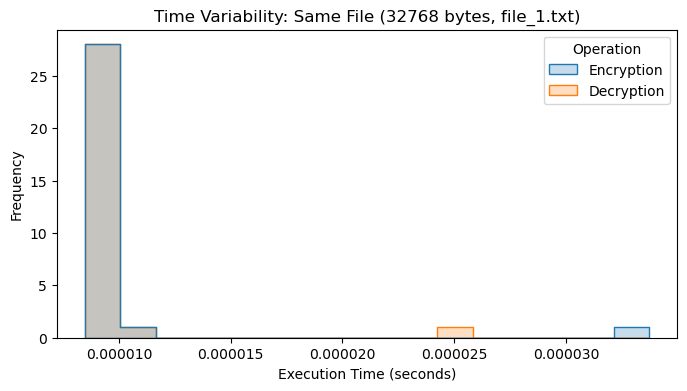

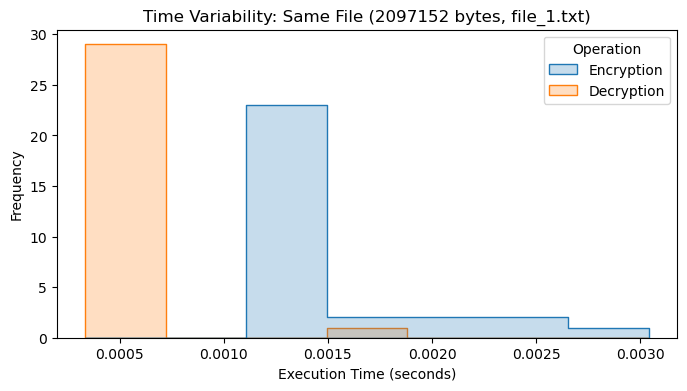

In [3]:
plot_variation_same_file(df,8)
plot_variation_same_file(df,32768)
plot_variation_same_file(df,2097152)

###### For better analysis let's take a look on performance of a fixed 8 Bytes size (the smaller), 32768 Bytes size (the intermediary) and the 2097152 Bytes size (the bigger), but it can be done with any bytes size, just calling the function with the 

##### Question B.2) And what if you run an algorithm over multiple randomly generated files of fixed size?

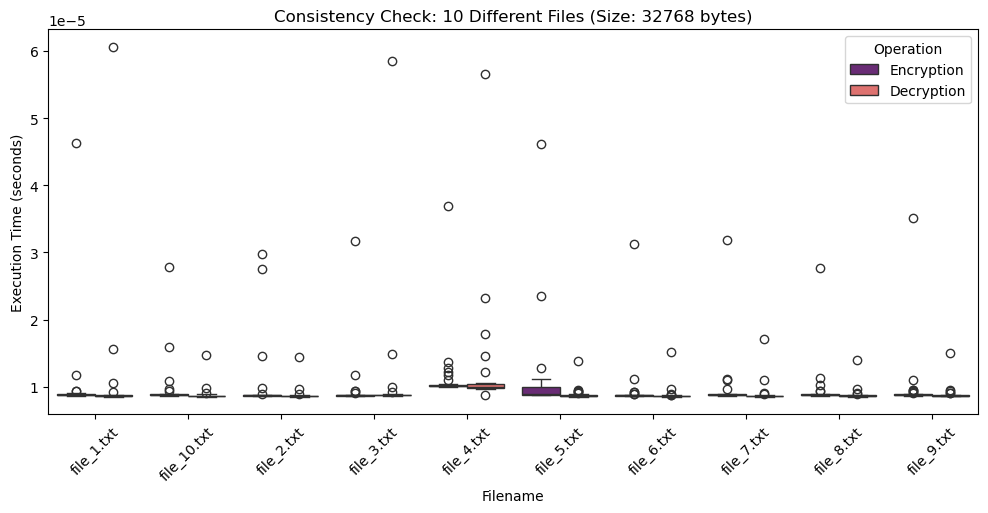

In [15]:
plot_comparison_fixed_size(df)

##### Final Analysis:

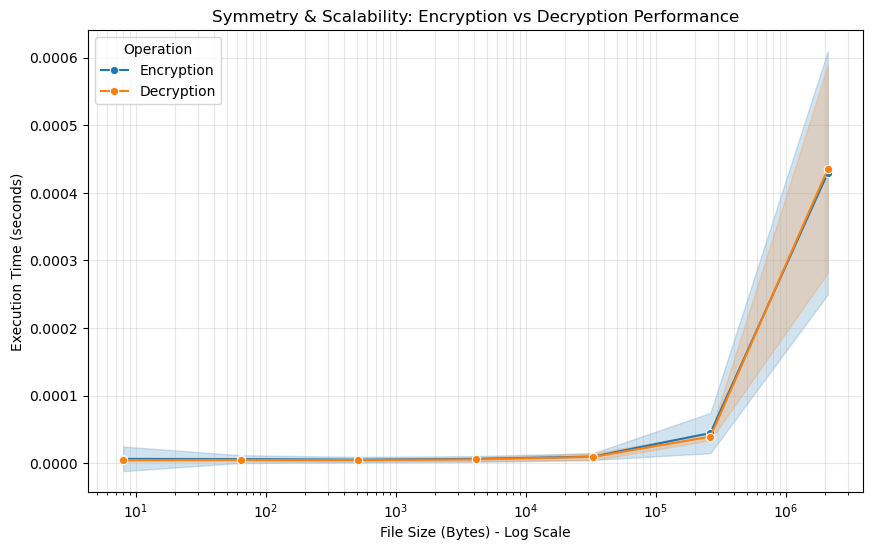

In [16]:
plot_final_scalability(df)